In [1]:
root = "C:/Users/v-wangwilli/projects/nepas"
setwd(root)
.libPaths(file.path(root, "renv/library/windows/R-4.4/x86_64-w64-mingw32"))

library(fixest)
library(tidyverse)

source("script/processors.R")

options(repr.plot.width = 12, repr.plot.height = 8, repr.plot.res = 300)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
bps = read_csv("data/cleaned_ocr/bps_final.csv")
bps_13balanced = bps |>
  filter(.by = smsa, n() == 13) |>
  mutate(
    adoption_year = if_else(adoption_year > 1979, Inf, adoption_year)
  )
bps_12 = bps |>
  filter(.by = smsa, n() >= 12)

Rows: 3204 Columns: 22
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): smsa, states, primary_state
dbl (19): year, total_units, private_total, private_1_unit, private_2_units,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
fepois(
  private_total ~ sunab(adoption_year, year) | smsa + year,
  data = bps_13balanced,
  cluster = ~ primary_state
) |> summary()

Warning message:
"The VCOV matrix is not positive semi-definite and was 'fixed' (see ?vcov)."


Poisson estimation, Dep. Var.: private_total
Observations: 1,287
Fixed-effects: smsa: 99,  year: 13
Standard-errors: Clustered (primary_state) 
           Estimate Std. Error   t value   Pr(>|t|)    
year::-10  0.256040   0.194470  1.316603 1.8797e-01    
year::-9   0.250281   0.237788  1.052541 2.9255e-01    
year::-8   0.194008   0.085633  2.265583 2.3477e-02 *  
year::-7   0.122622   0.097288  1.260405 2.0752e-01    
year::-6   0.026971   0.058056  0.464573 6.4224e-01    
year::-5  -0.029225   0.032754 -0.892268 3.7225e-01    
year::-4   0.171026   0.082967  2.061367 3.9268e-02 *  
year::-3  -0.147078   0.051215 -2.871794 4.0815e-03 ** 
year::-2  -0.090135   0.028827 -3.126765 1.7674e-03 ** 
year::0   -0.058345   0.041795 -1.395966 1.6272e-01    
year::1   -0.228786   0.047040 -4.863666 1.1523e-06 ***
year::2   -0.269690   0.041146 -6.554486 5.5834e-11 ***
year::3   -0.284008   0.043717 -6.496556 8.2179e-11 ***
year::4   -0.196582   0.035848 -5.483728 4.1645e-08 ***
year::5    0.171

Warning message:
"The VCOV matrix is not positive semi-definite and was 'fixed' (see ?vcov)."


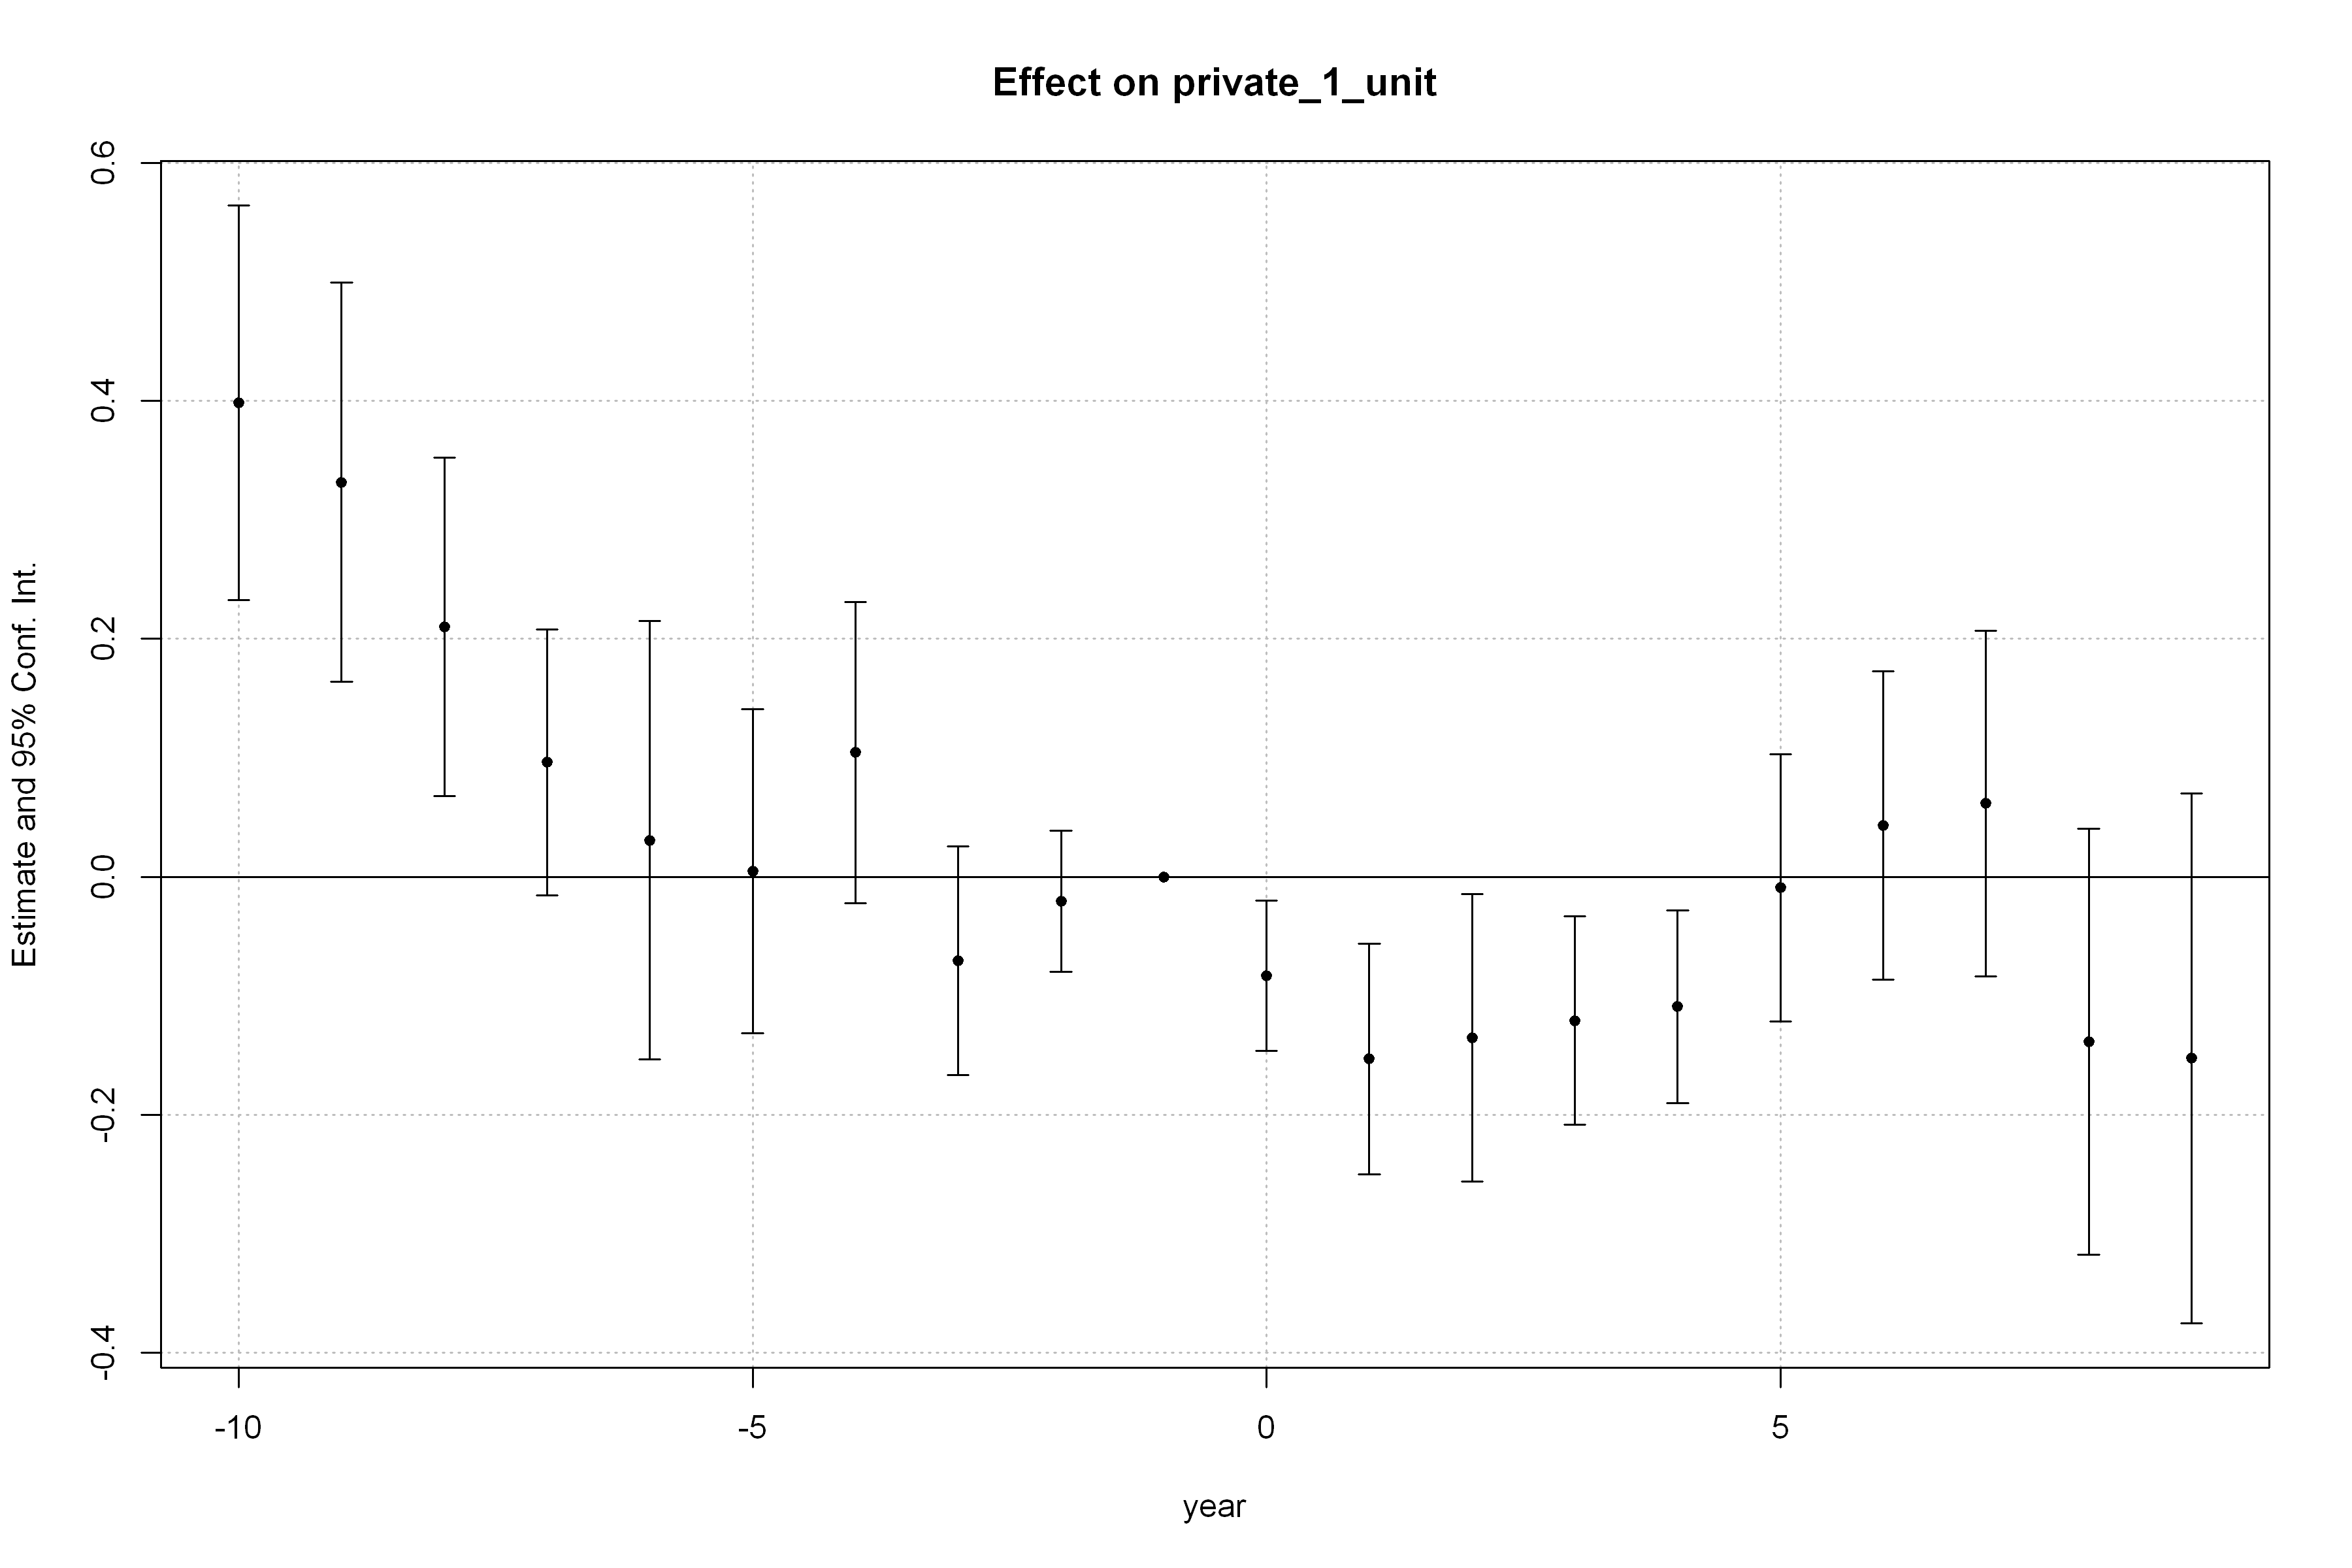

In [ ]:
fepois(
  private_1_unit ~ sunab(adoption_year, year) | smsa + year,
  data = bps_13balanced,
  cluster = ~ primary_state
) |> iplot()

Warning message:
"The VCOV matrix is not positive semi-definite and was 'fixed' (see ?vcov)."


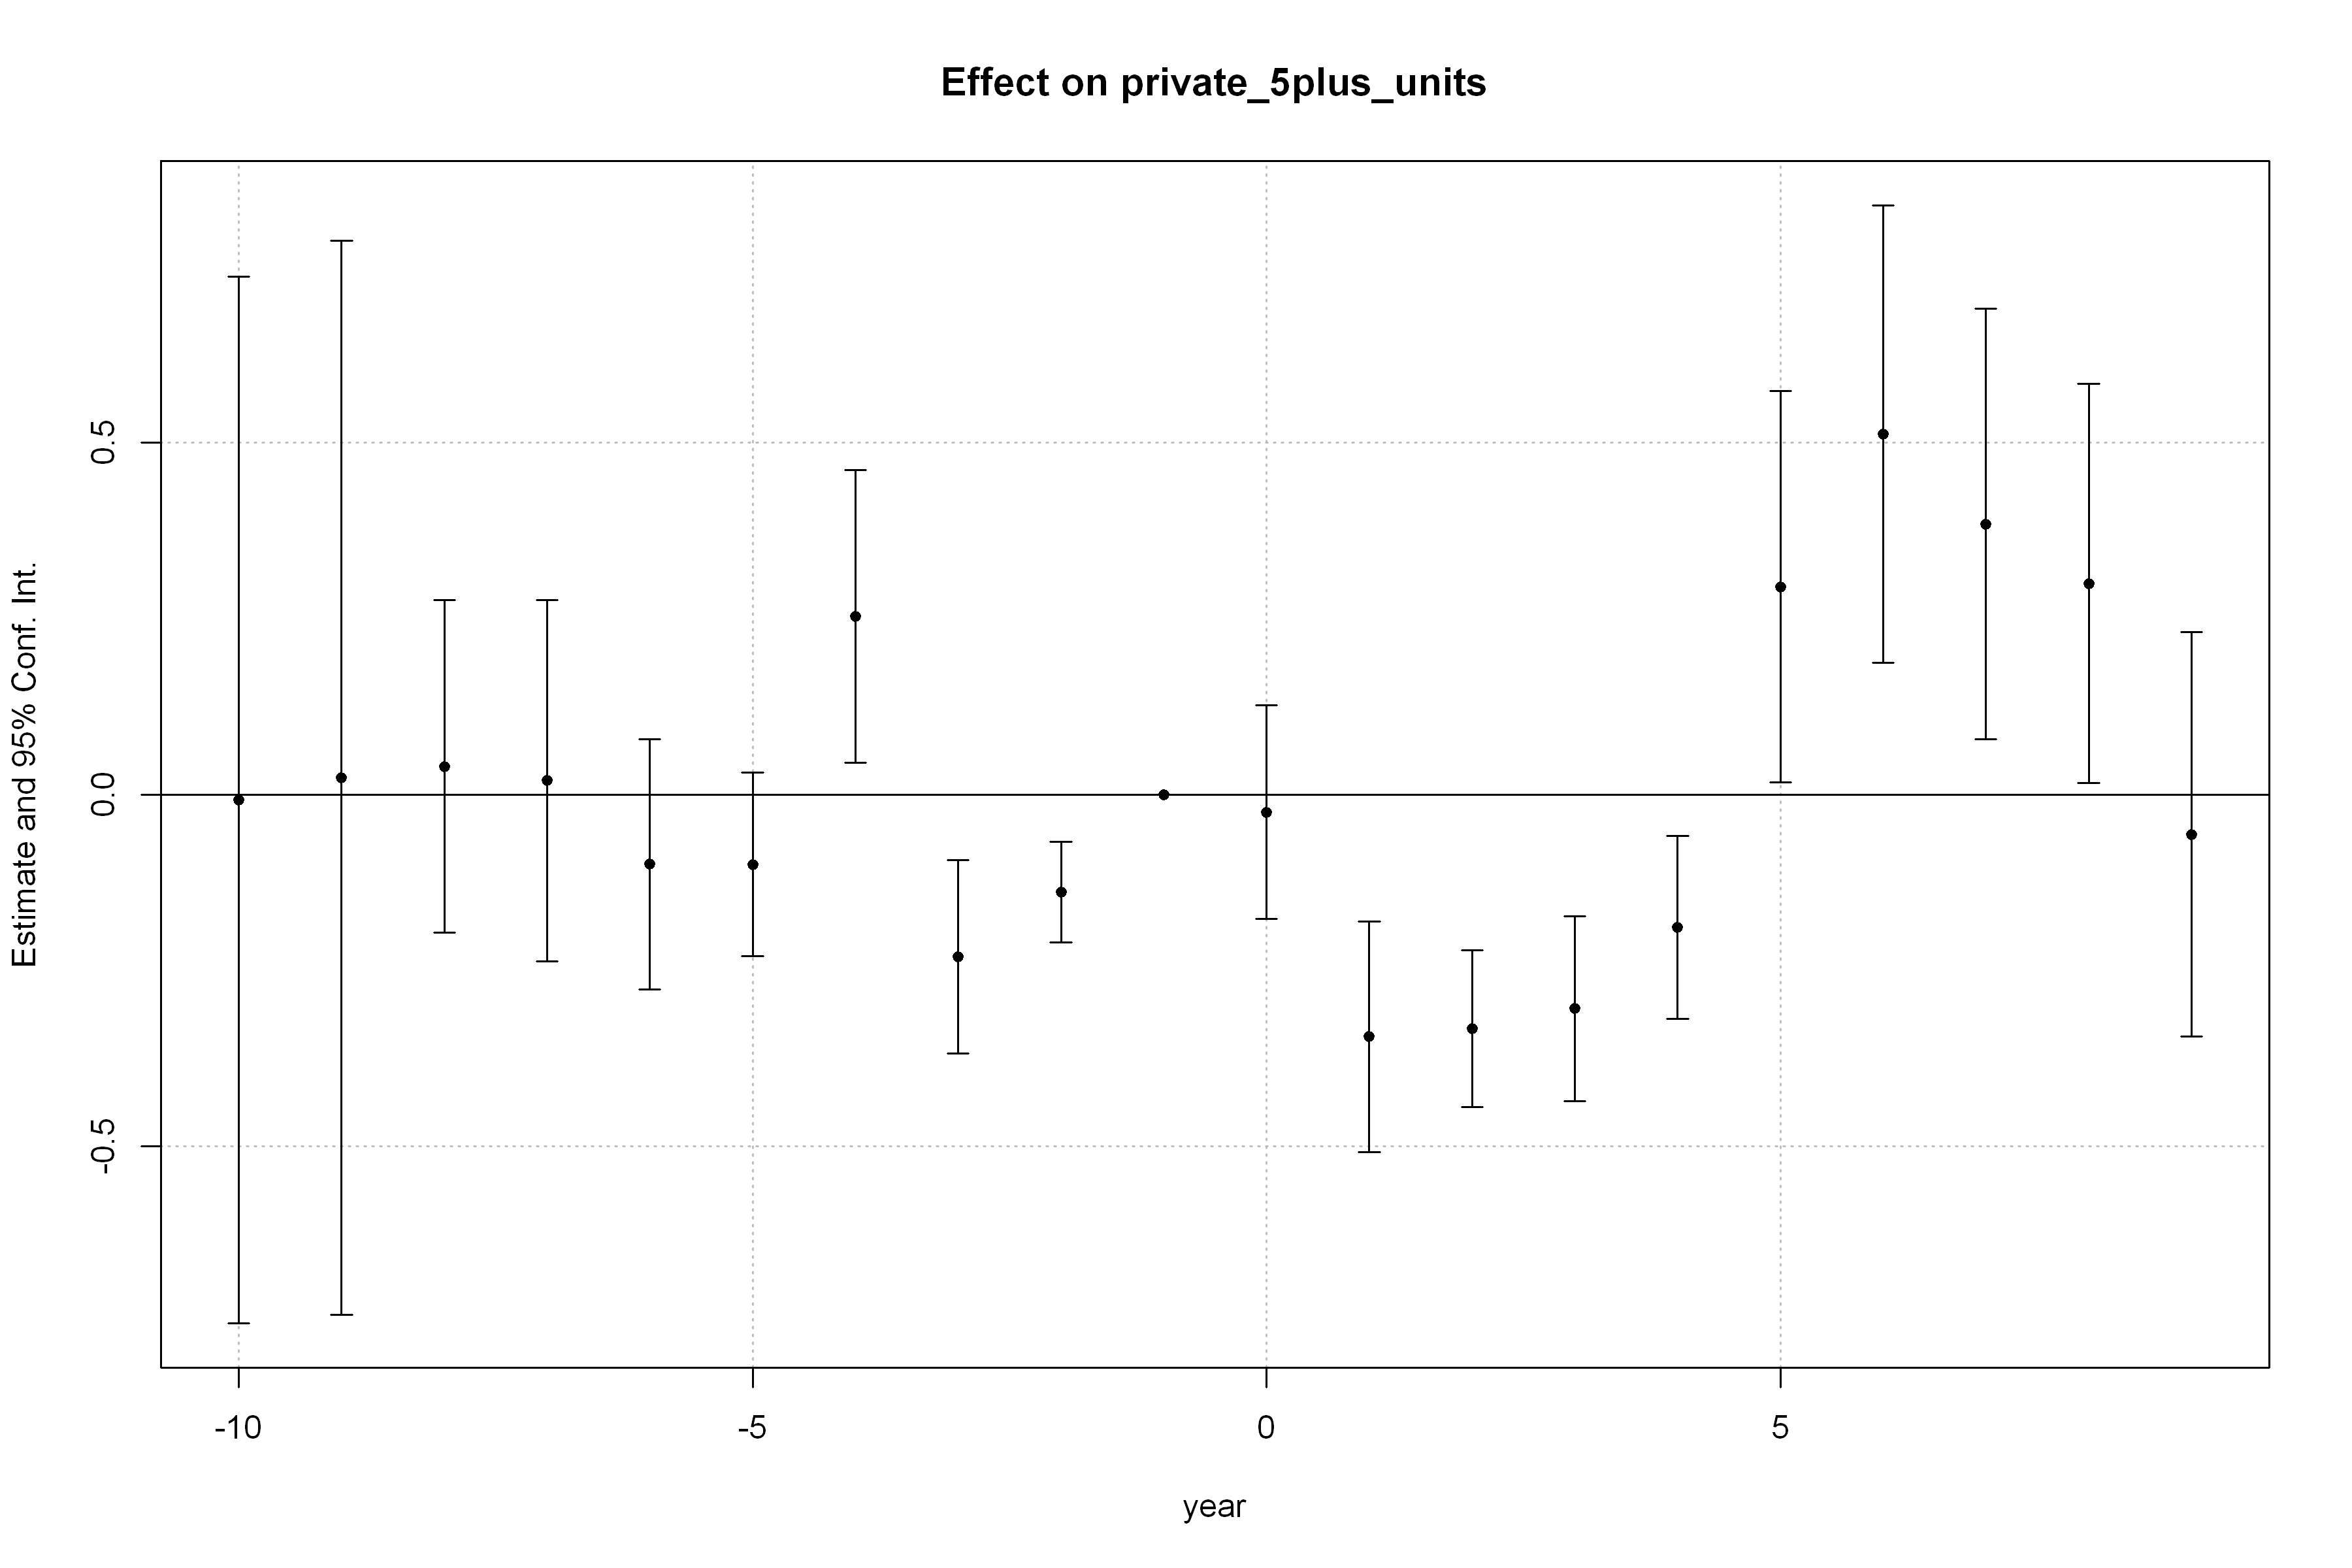

In [4]:
fepois(
  private_5plus_units ~ sunab(adoption_year, year) | smsa + year,
  data = bps_13balanced,
  cluster = ~ primary_state
) |> iplot()

In [5]:
fepois(
  private_total ~ sunab(adoption_year, year) | smsa + year,
  data = bps_12balanced,
  cluster = ~ primary_state
)

ERROR: Error in fepois(private_total ~ sunab(adoption_year, year) | smsa + year, : Argument 'data' could not be evaluated.
PROBLEM: object 'bps_12balanced' not found.


In [22]:
fepois(
  private_total ~ treat | smsa + year,
  data = bps_12balanced,
  cluster = ~ primary_state
)

Poisson estimation, Dep. Var.: private_total
Observations: 2,727
Fixed-effects: smsa: 219,  year: 13
Standard-errors: Clustered (primary_state) 
       Estimate Std. Error  z value Pr(>|z|) 
treat -0.120808   0.092172 -1.31067  0.18997 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Log-Likelihood:  -638,671.3   Adj. Pseudo R2: 0.94127 
           BIC: 1,279,177.9     Squared Cor.: 0.902336

In [ ]:
bps_design = bps_13balanced |>
  select(private_total, primary_state, treat) |>
  bind_cols(
    model.matrix(
      ~ i(adoption_year, ref = Inf) + i(year, ref = 1967) + i(adoption_year, i.year),
      data = bps_13balanced
    ) |> as_tibble()
  ) |>
  mutate(
    across(contains("adoption_year, i.year"), \(col) col * treat, .names = "treat_{.col}")  # in order to add pretreatment coefs, need to change this I think -- otherwise will always be 0?
  ) |>
  rename_with(
    \(col_names) str_replace(col_names, "i\\(adoption_year, ref = Inf\\)", "adoption_year_"),
    .cols = starts_with("i(adoption_year")
  ) |> 
  rename_with(
    \(col_names) str_replace(col_names, "i\\(year, ref = 1967\\)", "year_"),
    .cols = starts_with("i(year")
  ) |>
  select(!contains(",") | matches("^treat")) |>
#   pivot_longer(
#     cols = starts_with("treat_"),
#     names_to = c("adoption_year", "year"),
#     names_pattern = "treat_i\\(adoption_year, i.year\\)(.*):(.*)",
#     values_to = "value"
#   ) |>
#   filter(adoption_year <= year) |>
#   pivot_wider(
#     names_from = c("adoption_year", "year"),
#     names_glue = "treat_adoption{adoption_year}_year{year}",
#     values_from = "value"
#   )

names(bps_design)

[1] "private_total"               "primary_state"              
  [3] "treat"                       "(Intercept)"                
  [5] "adoption_year_1970"          "adoption_year_1971"         
  [7] "adoption_year_1972"          "adoption_year_1973"         
  [9] "adoption_year_1974"          "adoption_year_1975"         
 [11] "adoption_year_1977"          "year_1968"                  
 [13] "year_1969"                   "year_1970"                  
 [15] "year_1971"                   "year_1972"                  
 [17] "year_1973"                   "year_1974"                  
 [19] "year_1975"                   "year_1976"                  
 [21] "year_1977"                   "year_1978"                  
 [23] "year_1979"                   "treat_adoption1970_year1967"
 [25] "treat_adoption1970_year1968" "treat_adoption1970_year1969"
 [27] "treat_adoption1970_year1970" "treat_adoption1970_year1971"
 [29] "treat_adoption1970_year1972" "treat_adoption1970_year1973"
 [31] "treat_adoption1970_year1974" "treat_adoption1970_year1975"
 [33] "treat_adoption1970_year1976" "treat_adoption1970_year1977"
 [35] "treat_adoption1970_year1978" "treat_adoption1970_year1979"
 [37] "treat_adoption1971_year1967" "treat_adoption1971_year1968"
 [39] "treat_adoption1971_year1969" "treat_adoption1971_year1970"
 [41] "treat_adoption1971_year1971" "treat_adoption1971_year1972"
 [43] "treat_adoption1971_year1973" "treat_adoption1971_year1974"
 [45] "treat_adoption1971_year1975" "treat_adoption1971_year1976"
 [47] "treat_adoption1971_year1977" "treat_adoption1971_year1978"
 [49] "treat_adoption1971_year1979" "treat_adoption1972_year1967"
 [51] "treat_adoption1972_year1968" "treat_adoption1972_year1969"
 [53] "treat_adoption1972_year1970" "treat_adoption1972_year1971"
 [55] "treat_adoption1972_year1972" "treat_adoption1972_year1973"
 [57] "treat_adoption1972_year1974" "treat_adoption1972_year1975"
 [59] "treat_adoption1972_year1976" "treat_adoption1972_year1977"
 [61] "treat_adoption1972_year1978" "treat_adoption1972_year1979"
 [63] "treat_adoption1973_year1967" "treat_adoption1973_year1968"
 [65] "treat_adoption1973_year1969" "treat_adoption1973_year1970"
 [67] "treat_adoption1973_year1971" "treat_adoption1973_year1972"
 [69] "treat_adoption1973_year1973" "treat_adoption1973_year1974"
 [71] "treat_adoption1973_year1975" "treat_adoption1973_year1976"
 [73] "treat_adoption1973_year1977" "treat_adoption1973_year1978"
 [75] "treat_adoption1973_year1979" "treat_adoption1974_year1967"
 [77] "treat_adoption1974_year1968" "treat_adoption1974_year1969"
 [79] "treat_adoption1974_year1970" "treat_adoption1974_year1971"
 [81] "treat_adoption1974_year1972" "treat_adoption1974_year1973"
 [83] "treat_adoption1974_year1974" "treat_adoption1974_year1975"
 [85] "treat_adoption1974_year1976" "treat_adoption1974_year1977"
 [87] "treat_adoption1974_year1978" "treat_adoption1974_year1979"
 [89] "treat_adoption1975_year1967" "treat_adoption1975_year1968"
 [91] "treat_adoption1975_year1969" "treat_adoption1975_year1970"
 [93] "treat_adoption1975_year1971" "treat_adoption1975_year1972"
 [95] "treat_adoption1975_year1973" "treat_adoption1975_year1974"
 [97] "treat_adoption1975_year1975" "treat_adoption1975_year1976"
 [99] "treat_adoption1975_year1977" "treat_adoption1975_year1978"
[101] "treat_adoption1975_year1979" "treat_adoption1977_year1967"
[103] "treat_adoption1977_year1968" "treat_adoption1977_year1969"
[105] "treat_adoption1977_year1970" "treat_adoption1977_year1971"
[107] "treat_adoption1977_year1972" "treat_adoption1977_year1973"
[109] "treat_adoption1977_year1974" "treat_adoption1977_year1975"
[111] "treat_adoption1977_year1976" "treat_adoption1977_year1977"
[113] "treat_adoption1977_year1978" "treat_adoption1977_year1979"
[115] "treat_adoptionInf_year1967"  "treat_adoptionInf_year1968" 
[117] "treat_adoptionInf_year1969"  "treat_adoptionInf_year1970" 
[119] "treat_adoptionInf_year1971"  "treat_adoptionInf_year1972" 
[121] "treat_adoptionInf_year1973"  "treat

In [28]:
fepois(
  private_total ~ regex("adoption_year") + regex("year") + regex("treat_adoption"),
  data = bps_design,
  cluster = "primary_state"
)$collin.var

The variables 'treat_adoption1970_year1967', 'treat_adoption1970_year1968',
'treat_adoption1970_year1969', 'treat_adoption1971_year1967',
'treat_adoption1971_year1968', 'treat_adoption1971_year1969' and 50 others have
been removed because of collinearity (see $collin.var).

Warning message:
"The VCOV matrix is not positive semi-definite and was 'fixed' (see ?vcov)."


[1] "treat_adoption1970_year1967" "treat_adoption1970_year1968"
 [3] "treat_adoption1970_year1969" "treat_adoption1971_year1967"
 [5] "treat_adoption1971_year1968" "treat_adoption1971_year1969"
 [7] "treat_adoption1971_year1970" "treat_adoption1972_year1967"
 [9] "treat_adoption1972_year1968" "treat_adoption1972_year1969"
[11] "treat_adoption1972_year1970" "treat_adoption1972_year1971"
[13] "treat_adoption1973_year1967" "treat_adoption1973_year1968"
[15] "treat_adoption1973_year1969" "treat_adoption1973_year1970"
[17] "treat_adoption1973_year1971" "treat_adoption1973_year1972"
[19] "treat_adoption1974_year1967" "treat_adoption1974_year1968"
[21] "treat_adoption1974_year1969" "treat_adoption1974_year1970"
[23] "treat_adoption1974_year1971" "treat_adoption1974_year1972"
[25] "treat_adoption1974_year1973" "treat_adoption1975_year1967"
[27] "treat_adoption1975_year1968" "treat_adoption1975_year1969"
[29] "treat_adoption1975_year1970" "treat_adoption1975_year1971"
[31] "treat_adoption1975_year1972" "treat_adoption1975_year1973"
[33] "treat_adoption1975_year1974" "treat_adoption1977_year1967"
[35] "treat_adoption1977_year1968" "treat_adoption1977_year1969"
[37] "treat_adoption1977_year1970" "treat_adoption1977_year1971"
[39] "treat_adoption1977_year1972" "treat_adoption1977_year1973"
[41] "treat_adoption1977_year1974" "treat_adoption1977_year1975"
[43] "treat_adoption1977_year1976" "treat_adoptionInf_year1967" 
[45] "treat_adoptionInf_year1968"  "treat_adoptionInf_year1969" 
[47] "treat_adoptionInf_year1970"  "treat_adoptionInf_year1971" 
[49] "treat_adoptionInf_year1972"  "treat_adoptionInf_year1973" 
[51] "treat_adoptionInf_year1974"  "treat_adoptionInf_year1975" 
[53] "treat_adoptionInf_year1976"  "treat_adoptionInf_year1977" 
[55] "treat_adoptionInf_year1978"  "treat_adoptionInf_year1979"

In [30]:
fepois(
  private_total ~ i(adoption_year, ref = Inf) + i(year, ref = 1967) + i(adoption_year, i.year),
  data = bps_13balanced,
  cluster = ~ primary_state,
  glm.iter = 100
)

The variables 'adoption_year::1971:year::1979',
'adoption_year::1972:year::1979', 'adoption_year::1973:year::1979',
'adoption_year::1974:year::1979', 'adoption_year::1975:year::1979',
'adoption_year::1977:year::1979' and 13 others have been removed because of
collinearity (see $collin.var).

Warning message:
"The VCOV matrix is not positive semi-definite and was 'fixed' (see ?vcov)."


Poisson estimation, Dep. Var.: private_total
Observations: 1,287
Standard-errors: Clustered (primary_state) 
                     Estimate Std. Error   z value   Pr(>|z|)    
(Intercept)          8.943320   0.138207 64.709424  < 2.2e-16 ***
adoption_year::1970 -0.013823   0.138207 -0.100018 0.92033039    
adoption_year::1971  0.069947   0.277130  0.252399 0.80073300    
adoption_year::1972 -0.322263   0.338459 -0.952146 0.34102274    
adoption_year::1973 -0.485107   0.448254 -1.082214 0.27915737    
adoption_year::1974 -0.669132   0.183148 -3.653512 0.00025868 ***
adoption_year::1975 -0.540803   0.183148 -2.952826 0.00314880 ** 
adoption_year::1977 -0.434526   0.252282 -1.722382 0.08500027 .  
... 96 coefficients remaining (display them with summary() or use
argument n)
... 19 variables were removed because of collinearity
(adoption_year::1971:year::1979, adoption_year::1972:year::1979 and 17
others [full set in $collin.var])
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1

In [11]:
fepois(
  private_total ~ i(year, i.adoption_year) | smsa + year,
  data = bps_13balanced,
  cluster = ~ primary_state 
) |> summary()

The variables 'year::1968:adoption_year::Inf', 'year::1969:adoption_year::Inf',
'year::1970:adoption_year::Inf', 'year::1971:adoption_year::Inf',
'year::1972:adoption_year::Inf', 'year::1973:adoption_year::Inf' and 13 others
have been removed because of collinearity (see $collin.var).

Warning message:
"The VCOV matrix is not positive semi-definite and was 'fixed' (see ?vcov)."


Poisson estimation, Dep. Var.: private_total
Observations: 1,287
Fixed-effects: smsa: 99,  year: 13
Standard-errors: Clustered (primary_state) 
                                Estimate Std. Error       z value   Pr(>|z|)
year::1967:adoption_year::1971  0.441895 0.14292121  3.091877e+00 1.9890e-03
year::1967:adoption_year::1972  0.691815 0.10545736  6.560144e+00 5.3756e-11
year::1967:adoption_year::1973  0.755817 0.05680991  1.330432e+01  < 2.2e-16
year::1967:adoption_year::1974  0.762431 0.00000100  7.624311e+05  < 2.2e-16
year::1967:adoption_year::1975  1.333836 0.00000100  1.333836e+06  < 2.2e-16
year::1967:adoption_year::1977  0.795420 0.18316242  4.342704e+00 1.4074e-05
year::1967:adoption_year::Inf   0.303669 0.16913594  1.795416e+00 7.2587e-02
year::1968:adoption_year::1970 -0.100704 0.12789324 -7.874080e-01 4.3104e-01
year::1968:adoption_year::1971  0.084282 0.17436281  4.833720e-01 6.2883e-01
year::1968:adoption_year::1972  0.365716 0.16210757  2.256007e+00 2.4070e-02
year::196